In [11]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

In [12]:
df = pl.read_csv("../data/raw/social_media_vs_productivity.csv")

## Impelmentacion basica, lo que quiero es que se ejecuten en paralelo automaticamen 

In [13]:
def etl_pipeline():
    df = pl.read_csv("../data/raw/social_media_vs_productivity.csv")
 

    # Identificar tipos de columnas
    numeric_cols = [col for col in df.columns if df[col].dtype in [pl.Float64, pl.Int64]]
    categorical_cols = [col for col in df.columns if col not in numeric_cols]

    # Transformación con manejo adecuado por tipo de columna
    df_transformed = df.with_columns([
        # Para columnas numéricas: usar mediana
        *[pl.col(col).fill_null(pl.col(col).median()) for col in numeric_cols],

        # Para columnas categóricas: usar modo (valor más frecuente) o un valor predeterminado
        *[pl.col(col).fill_null(pl.col(col).mode().first()) for col in categorical_cols],

        # Características derivadas (solo para columnas numéricas)
        (pl.col("number_of_notifications") * pl.col("daily_social_media_time")).alias("distraction_index"),

        # Categorización
        pl.when(pl.col("daily_social_media_time") > 5)
          .then(pl.lit("high"))
          .when(pl.col("daily_social_media_time") > 2)
          .then(pl.lit("medium"))
          .otherwise(pl.lit("low"))
          .alias("social_usage_category")
    ])

    # Agregaciones
    summary = df_transformed.group_by(["job_type", "social_usage_category"]).agg([
        pl.len().alias("count"),
        pl.mean("actual_productivity_score").alias("avg_productivity"),
        pl.mean("distraction_index").alias("avg_distraction"),
        pl.mean("stress_level").alias("avg_stress")
    ])

    # Retornar resultados
    return df_transformed, summary

# Ejecutar pipeline
transformed_data, summary_data = etl_pipeline()

In [14]:
etl_pipeline()

(shape: (30_000, 21)
 ┌──────┬────────┬────────────┬─────────────┬───┬────────────┬────────────┬────────────┬────────────┐
 │ age  ┆ gender ┆ job_type   ┆ daily_socia ┆ … ┆ weekly_off ┆ job_satisf ┆ distractio ┆ social_usa │
 │ ---  ┆ ---    ┆ ---        ┆ l_media_tim ┆   ┆ line_hours ┆ action_sco ┆ n_index    ┆ ge_categor │
 │ f64  ┆ str    ┆ str        ┆ e           ┆   ┆ ---        ┆ re         ┆ ---        ┆ y          │
 │      ┆        ┆            ┆ ---         ┆   ┆ f64        ┆ ---        ┆ f64        ┆ ---        │
 │      ┆        ┆            ┆ f64         ┆   ┆            ┆ f64        ┆            ┆ str        │
 ╞══════╪════════╪════════════╪═════════════╪═══╪════════════╪════════════╪════════════╪════════════╡
 │ 56.0 ┆ Male   ┆ Unemployed ┆ 4.18094     ┆ … ┆ 21.927072  ┆ 6.336688   ┆ 255.037326 ┆ medium     │
 │ 46.0 ┆ Male   ┆ Health     ┆ 3.249603    ┆ … ┆ 0.0        ┆ 3.412427   ┆ 191.726574 ┆ medium     │
 │ 32.0 ┆ Male   ┆ Finance    ┆ 3.025913    ┆ … ┆ 10.322044  

In [15]:
print(transformed_data)

shape: (30_000, 21)
┌──────┬────────┬────────────┬─────────────┬───┬────────────┬────────────┬────────────┬────────────┐
│ age  ┆ gender ┆ job_type   ┆ daily_socia ┆ … ┆ weekly_off ┆ job_satisf ┆ distractio ┆ social_usa │
│ ---  ┆ ---    ┆ ---        ┆ l_media_tim ┆   ┆ line_hours ┆ action_sco ┆ n_index    ┆ ge_categor │
│ f64  ┆ str    ┆ str        ┆ e           ┆   ┆ ---        ┆ re         ┆ ---        ┆ y          │
│      ┆        ┆            ┆ ---         ┆   ┆ f64        ┆ ---        ┆ f64        ┆ ---        │
│      ┆        ┆            ┆ f64         ┆   ┆            ┆ f64        ┆            ┆ str        │
╞══════╪════════╪════════════╪═════════════╪═══╪════════════╪════════════╪════════════╪════════════╡
│ 56.0 ┆ Male   ┆ Unemployed ┆ 4.18094     ┆ … ┆ 21.927072  ┆ 6.336688   ┆ 255.037326 ┆ medium     │
│ 46.0 ┆ Male   ┆ Health     ┆ 3.249603    ┆ … ┆ 0.0        ┆ 3.412427   ┆ 191.726574 ┆ medium     │
│ 32.0 ┆ Male   ┆ Finance    ┆ 3.025913    ┆ … ┆ 10.322044  ┆ 2.474944 

### Integrando inteligencia

In [16]:
from sklearn.ensemble import IsolationForest

def detect_anomalies(df):
    # Seleccionar características numéricas relevantes
    features = ["daily_social_media_time", "work_hours_per_day",
                "actual_productivity_score", "stress_level"]

    '''Convertir a numpy para el modelo'''
    X = df.select(features).fill_null(pl.all().median()).to_numpy()

    '''Entrenar modelo de detección de anomalías'''
    model = IsolationForest(contamination=0.05, random_state=42)
    anomaly_scores = model.fit_predict(X)

    return df.with_columns(
        pl.lit(anomaly_scores).alias("anomaly_flag").map_elements(lambda x: x == -1)
    )

### Preciso hacer un cluster para poder trabajar con los vecinos mas cercanos para poder analizar las caracteristicas de cada segmento.

In [17]:
from sklearn.cluster import KMeans

def segment_users(df):
    # Preparar características para clustering
    features = ["daily_social_media_time", "actual_productivity_score",
                "stress_level", "sleep_hours", "breaks_during_work"]

    '''Datos limpios para clustering'''
    X = df.select(features).fill_null(pl.all().median()).to_numpy()

    '''Aplicar K-Means'''
    kmeans = KMeans(n_clusters=4, random_state=42)
    clusters = kmeans.fit_predict(X)

    '''Añadir segmentos al dataframe'''
    df_with_segments = df.with_columns(
        pl.lit(clusters).alias("user_segment")
    )

    '''Analizar características de cada segmento'''
    segment_profiles = df_with_segments.group_by("user_segment").agg([
        pl.len().alias("count"),
        pl.mean("daily_social_media_time").alias("avg_social_media"),
        pl.mean("actual_productivity_score").alias("avg_productivity"),
        pl.mean("stress_level").alias("avg_stress")
    ])

    return df_with_segments, segment_profiles

In [18]:
df_segmented, segment_profiles = segment_users(df)
print(segment_profiles)

shape: (4, 5)
┌──────────────┬───────┬──────────────────┬──────────────────┬────────────┐
│ user_segment ┆ count ┆ avg_social_media ┆ avg_productivity ┆ avg_stress │
│ ---          ┆ ---   ┆ ---              ┆ ---              ┆ ---        │
│ i32          ┆ u32   ┆ f64              ┆ f64              ┆ f64        │
╞══════════════╪═══════╪══════════════════╪══════════════════╪════════════╡
│ 3            ┆ 7264  ┆ 3.157148         ┆ 4.949505         ┆ 7.977698   │
│ 2            ┆ 7670  ┆ 3.082939         ┆ 4.953759         ┆ 3.009257   │
│ 1            ┆ 8706  ┆ 3.066107         ┆ 4.959852         ┆ 8.024824   │
│ 0            ┆ 6360  ┆ 3.164575         ┆ 4.941032         ┆ 3.029403   │
└──────────────┴───────┴──────────────────┴──────────────────┴────────────┘


### Entrenar el Modelo de con RANDOM FOREST

<Figure size 1000x600 with 0 Axes>

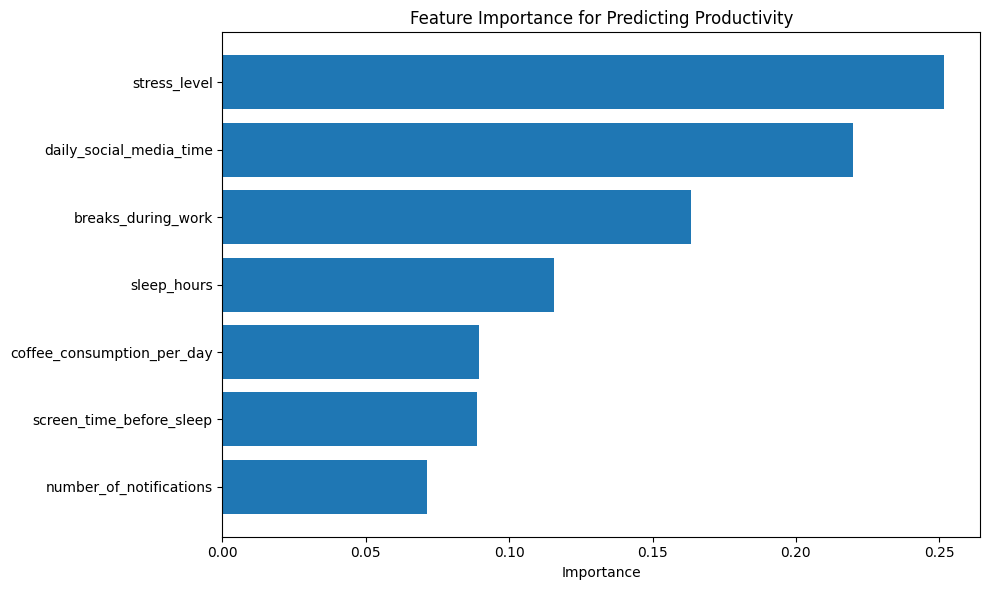

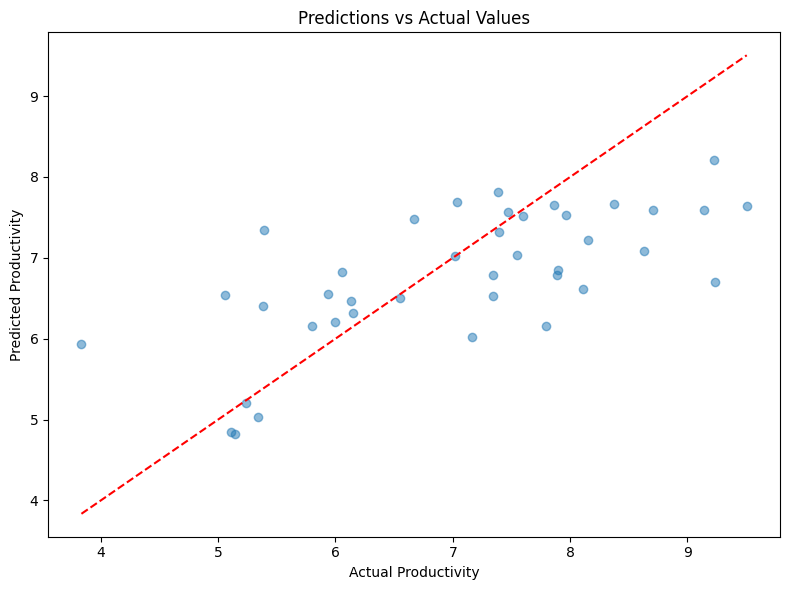

Mean Squared Error (MSE): 1.0659
Coefficient of Determination (R²): 0.4258

Feature Importance:
  stress_level: 0.2516
  daily_social_media_time: 0.2199
  breaks_during_work: 0.1634
  sleep_hours: 0.1156
  coffee_consumption_per_day: 0.0894
  screen_time_before_sleep: 0.0889
  number_of_notifications: 0.0712


In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Crear datos de ejemplo para simular el dataframe
np.random.seed(42)
n_samples = 200

# Simular características
daily_social_media = np.random.normal(120, 45, n_samples)
notifications = np.random.normal(50, 20, n_samples)
sleep_hours = np.random.normal(7, 1.2, n_samples)
breaks = np.random.normal(4, 2, n_samples)
stress_level = np.random.normal(6, 2, n_samples)
coffee = np.random.normal(2.5, 1.5, n_samples)
screen_before_sleep = np.random.normal(45, 20, n_samples)

# Crear productividad con relaciones simuladas
productivity = (
    8 
    - 0.01 * daily_social_media 
    - 0.005 * notifications 
    + 0.3 * sleep_hours 
    + 0.2 * breaks 
    - 0.4 * stress_level 
    + 0.1 * coffee 
    - 0.01 * screen_before_sleep
) + np.random.normal(0, 1, n_samples)  # Añadir ruido

# Crear matriz de características
X = np.column_stack([
    daily_social_media, notifications, sleep_hours, breaks, 
    stress_level, coffee, screen_before_sleep
])
y = productivity

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar modelo
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluar modelo
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Identificar factores importantes
features = [
    "daily_social_media_time", "number_of_notifications",
    "sleep_hours", "breaks_during_work", "stress_level",
    "coffee_consumption_per_day", "screen_time_before_sleep"
]
feature_importance = sorted(zip(features, model.feature_importances_),
                           key=lambda x: x[1], reverse=True)

plt.figure(figsize=(10, 6))
importance_df = sorted(zip(features, model.feature_importances_), key=lambda x: x[1])
features_sorted = [x[0] for x in importance_df]
importance_sorted = [x[1] for x in importance_df]


plt.figure(figsize=(10, 6))
importance_df = sorted(zip(features, model.feature_importances_), key=lambda x: x[1])
features_sorted = [x[0] for x in importance_df]
importance_sorted = [x[1] for x in importance_df]

plt.barh(range(len(features_sorted)), importance_sorted)
plt.yticks(range(len(features_sorted)), features_sorted)
plt.xlabel('Importance')
plt.title('Feature Importance for Predicting Productivity')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Productivity')
plt.ylabel('Predicted Productivity')
plt.title('Predictions vs Actual Values')
plt.tight_layout()
plt.show()


print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Coefficient of Determination (R²): {r2:.4f}")
print("\nFeature Importance:")
for feature, importance in feature_importance:
    print(f"  {feature}: {importance:.4f}")

In [21]:
def generate_recommendations(df):
    ''' Añadir columnas de análisis'''
    df_analyzed = df.with_columns([
        (pl.col("perceived_productivity_score") - pl.col("actual_productivity_score"))
            .alias("productivity_perception_gap"),
        (pl.col("daily_social_media_time") / pl.col("work_hours_per_day"))
            .alias("social_media_ratio")
    ])

    '''Reglas para recomendaciones personalizadas'''
    recommendations = []

    for row in df_analyzed.iter_rows(named=True):
        user_recs = []

        # Recomendaciones basadas en patrones
        if row.get("social_media_ratio", 0) > 0.3:
            user_recs.append("Reducir tiempo en redes sociales durante horas laborales")

        if row.get("stress_level", 0) > 7:
            user_recs.append("Implementar técnicas de manejo de estrés")

        if row.get("breaks_during_work", 0) < 3:
            user_recs.append("Aumentar frecuencia de descansos durante el trabajo")

        if row.get("sleep_hours", 0) < 6:
            user_recs.append("Mejorar hábitos de sueño")

        if row.get("productivity_perception_gap", 0) > 2:
            user_recs.append("Ajustar expectativas de productividad")

        recommendations.append(user_recs)

   # Añadir recomendaciones al dataframe
    df_with_recs = df_analyzed.with_columns(
        pl.lit(recommendations).alias("personalized_recommendations")
    )


    return df_with_recs

### Prueba

In [27]:
np.random.seed(42)
n = 5  # Número de usuarios

# Crear dataframe de ejemplo
data = {
    "user_id": [f"user_{i}" for i in range(1, n+1)],
    "perceived_productivity_score": np.random.randint(1, 11, n),
    "actual_productivity_score": np.random.randint(1, 11, n),
    "daily_social_media_time": np.random.randint(0, 5, n),
    "work_hours_per_day": np.random.randint(6, 10, n),
    "stress_level": np.random.randint(1, 11, n),
    "breaks_during_work": np.random.randint(0, 6, n),
    "sleep_hours": np.random.randint(4, 10, n)
}

df = pl.DataFrame(data)
print("Datos originales:")
print(df)

# Función de recomendaciones
def generate_recommendations(df):
    ''' Añadir columnas de análisis'''
    df_analyzed = df.with_columns([
        (pl.col("perceived_productivity_score") - pl.col("actual_productivity_score"))
            .alias("productivity_perception_gap"),
        (pl.col("daily_social_media_time") / pl.col("work_hours_per_day"))
            .alias("social_media_ratio")
    ])

    '''Reglas para recomendaciones personalizadas'''
    recommendations = []

    for row in df_analyzed.iter_rows(named=True):
        user_recs = []

        # Recomendaciones basadas en patrones
        if row.get("social_media_ratio", 0) > 0.3:
            user_recs.append("Reducir tiempo en redes sociales durante horas laborales")

        if row.get("stress_level", 0) > 7:
            user_recs.append("Implementar técnicas de manejo de estrés")

        if row.get("breaks_during_work", 0) < 3:
            user_recs.append("Aumentar frecuencia de descansos durante el trabajo")

        if row.get("sleep_hours", 0) < 6:
            user_recs.append("Mejorar hábitos de sueño")

        if row.get("productivity_perception_gap", 0) > 2:
            user_recs.append("Ajustar expectativas de productividad")

        recommendations.append(user_recs)

    # Añadir recomendaciones al dataframe
    df_with_recs = df_analyzed.with_columns(
        pl.Series(recommendations).alias("personalized_recommendations")
    )

    return df_with_recs

# Ejecutar la función
result = generate_recommendations(df)
print("\nResultado con recomendaciones:")
print(result)

Datos originales:
shape: (5, 8)
┌─────────┬────────────┬────────────┬────────────┬────────────┬────────────┬───────────┬───────────┐
│ user_id ┆ perceived_ ┆ actual_pro ┆ daily_soci ┆ work_hours ┆ stress_lev ┆ breaks_du ┆ sleep_hou │
│ ---     ┆ productivi ┆ ductivity_ ┆ al_media_t ┆ _per_day   ┆ el         ┆ ring_work ┆ rs        │
│ str     ┆ ty_score   ┆ score      ┆ ime        ┆ ---        ┆ ---        ┆ ---       ┆ ---       │
│         ┆ ---        ┆ ---        ┆ ---        ┆ i32        ┆ i32        ┆ i32       ┆ i32       │
│         ┆ i32        ┆ i32        ┆ i32        ┆            ┆            ┆           ┆           │
╞═════════╪════════════╪════════════╪════════════╪════════════╪════════════╪═══════════╪═══════════╡
│ user_1  ┆ 7          ┆ 10         ┆ 3          ┆ 7          ┆ 5          ┆ 0         ┆ 7         │
│ user_2  ┆ 4          ┆ 3          ┆ 2          ┆ 7          ┆ 1          ┆ 2         ┆ 9         │
│ user_3  ┆ 8          ┆ 7          ┆ 4          ┆ 7       